In [1]:
# Create a model to predict the selling price of the car. Split the data for prediction purposes.

# Initialization

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [3]:
car_data = pd.read_csv('car_dataset.csv')
car_data


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


# Cleaning

In [22]:
print(np.mean(car_data['selling_price']))

637810.401728395


In [4]:
car_data = car_data[car_data['km_driven'] < 300000]
car_data = car_data[car_data['selling_price'] < 8000000]

In [5]:
car_data['mileage_numeric'] = car_data['mileage'].str.replace(r'[^0-9.]', '', regex=True).replace('Nan', '0', regex= False).astype(float)

In [6]:
car_data['max_power_numeric'] = car_data['max_power'].str.replace(r'[^0-9.]', '', regex=True).replace('', '0').fillna('0').astype(float)


In [7]:
car_data['selling_price'].corr(car_data['max_power_numeric'])

0.7189260206922332

<Axes: xlabel='max_power_numeric', ylabel='selling_price'>

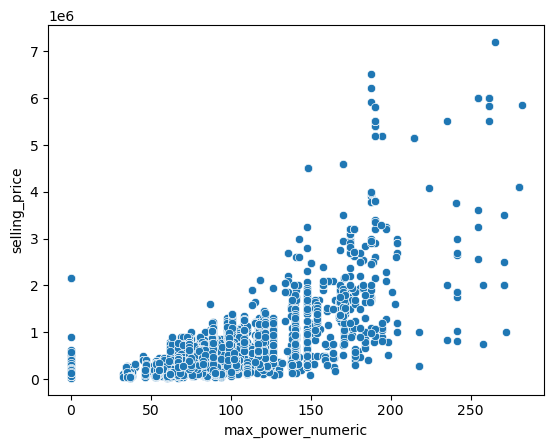

In [8]:
sns.scatterplot(x = 'max_power_numeric', y = 'selling_price', data = car_data)

# Training

Things to train on:  
km_driven,  
year,  
max_power_numeric

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error



In [10]:
X = car_data[['year','km_driven','max_power_numeric']]
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)
y = car_data[['selling_price']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size= 0.33
)


In [ ]:
#I am randomly choosing and adjusting alpha. I am using the l2 penalty because I have already pre-screened the input variables and know that they are not meaningless. 
#Nevermind. Wrote that first one before testing all the l1's possible. Turns out the ratio should be 1.
def find_mse (alpha, l1):    
    eNet = ElasticNet(alpha= alpha, l1_ratio= l1)
    eNet.fit(X_train, y_train)
    preds = eNet.predict(X_test)
    mse = mean_squared_error(preds, y_test)
    # print(np.mean(y_test), np.mean(preds))
    
    # print(alpha, " : ", mse)
    return mse

In [27]:
best_alpha = 1000
best_l1_ratio = 2
mse_best_alpha = 10000000000000000000000000000
for i in range(0,1000, 20):
    for j in np.arange(0,1.1, 0.2):
        mse_i = find_mse(i,j)
        if mse_i < mse_best_alpha:
            best_alpha = i
            best_l1_ratio = j
            mse_best_alpha = mse_i
print(best_alpha, best_l1_ratio, np.sqrt(mse_best_alpha))

c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\base.py:1151: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.399e+14, tolerance: 3.996e+11 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinat

980 1.0 503982.8437466403


c:\Users\jehow\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.996e+15, tolerance: 3.996e+11 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


The best model is a lasso model with an alpha of 980.